# late interaction alignment: UNI2 + Novae

independent MLP projections for each modality -> shared space -> InfoNCE.
tests H1: aligned embeddings retrieve better cross-modal matches than baselines.

one notebook, multiple runs. change the config cell, run all, results go to `runs/tnbc-92/{EXP_ID}/`.
comparison cell at the bottom loads all runs.

In [14]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial import KDTree
import subprocess, io, json, time
import pandas as pd

sns.set_theme(style='ticks', palette='Dark2', context='notebook')

ROOT = Path().resolve().parents[1]
EMB_DIR = ROOT / 'data' / 'embeddings'
RUNS_DIR = ROOT / 'runs' / 'tnbc-92'
DATA = ROOT / 'data' / 'inputs' / 'byArray'
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'device: {device}')

device: mps


## config — change this cell only

In [15]:
EXP_ID = 'exp01d'

CONFIG = {
    # encoders
    'he_encoder': 'uni2_reinhard',
    'st_encoder': 'novae',
    'he_dim': 1536,
    'st_dim': 64,
    
    # data split
    'subarrays': ['TNBC83_CN42_C1', 'TNBC1_CN1_C1', 'TNBC3_CN2_C1'],
    'split': 'random_spot_80_10_10',
    'val_fraction': 0.1,
    'test_fraction': 0.1,
    
    # architecture
    'shared_dim': 512,
    'dropout': 0.3,  # exp01b used 0.0
    
    # training
    'batch_size': 256,
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'epochs': 100,
    'temperature': 0.07,
    'patience': 15,
    'warmup_epochs': 0,
    'early_stopping_metric': 'val_loss',  # back to val_loss (exp01c showed vpc is wrong)
    'early_stopping_mode': 'min',
}

print(f'experiment: {EXP_ID}')
print(f'change from exp01b: dropout={CONFIG["dropout"]}')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')


experiment: exp01d
change from exp01b: dropout=0.3
  he_encoder: uni2_reinhard
  st_encoder: novae
  he_dim: 1536
  st_dim: 64
  subarrays: ['TNBC83_CN42_C1', 'TNBC1_CN1_C1', 'TNBC3_CN2_C1']
  split: random_spot_80_10_10
  val_fraction: 0.1
  test_fraction: 0.1
  shared_dim: 512
  dropout: 0.3
  batch_size: 256
  lr: 0.001
  weight_decay: 0.0001
  epochs: 100
  temperature: 0.07
  patience: 15
  warmup_epochs: 0
  early_stopping_metric: val_loss
  early_stopping_mode: min


## data loading + split

In [16]:
# load and concatenate all subarrays
he_all, st_all, labels_all = [], [], []
for key in CONFIG['subarrays']:
    he = np.load(EMB_DIR / CONFIG['he_encoder'] / f'{key}.npy')
    st = np.load(EMB_DIR / CONFIG['st_encoder'] / f'{key}.npy')
    assert he.shape[0] == st.shape[0], f'{key}: H&E {he.shape[0]} != ST {st.shape[0]}'
    he_all.append(he)
    st_all.append(st)
    labels_all.extend([key] * he.shape[0])
    print(f'{key}: {he.shape[0]} matched pairs')

he_all = np.vstack(he_all)
st_all = np.vstack(st_all)
labels_all = np.array(labels_all)
N = he_all.shape[0]
print(f'\ntotal: {N} matched pairs (H&E {he_all.shape[1]}-d, ST {st_all.shape[1]}-d)')

# raw signal check: K-NN overlap between modalities
from sklearn.metrics.pairwise import cosine_distances
K_CHECK = 20
he_nn = np.argsort(cosine_distances(he_all), axis=1)[:, 1:K_CHECK+1]
st_nn = np.argsort(cosine_distances(st_all), axis=1)[:, 1:K_CHECK+1]
knn_overlap = np.mean([len(set(he_nn[i]) & set(st_nn[i])) for i in range(N)])
knn_overlap_fraction = knn_overlap / K_CHECK
print(f'\ncross-modal K-NN overlap: {knn_overlap:.2f}/{K_CHECK} ({knn_overlap_fraction:.1%})')
print(f'raw signal ceiling estimate: R@1 ~= {knn_overlap_fraction:.3f}')

TNBC83_CN42_C1: 1398 matched pairs
TNBC1_CN1_C1: 1075 matched pairs
TNBC3_CN2_C1: 701 matched pairs

total: 3174 matched pairs (H&E 1536-d, ST 64-d)

cross-modal K-NN overlap: 1.71/20 (8.5%)
raw signal ceiling estimate: R@1 ~= 0.085


In [17]:
# split
n_test = int(N * CONFIG['test_fraction'])
n_val = int(N * CONFIG['val_fraction'])
n_train = N - n_val - n_test

idx = np.random.permutation(N)
train_idx = idx[:n_train]
val_idx = idx[n_train:n_train + n_val]
test_idx = idx[n_train + n_val:]

he_train, st_train = he_all[train_idx], st_all[train_idx]
he_val, st_val = he_all[val_idx], st_all[val_idx]
he_test, st_test = he_all[test_idx], st_all[test_idx]

# log subarray distribution per split
for name, idxs in [('train', train_idx), ('val', val_idx), ('test', test_idx)]:
    labs = labels_all[idxs]
    counts = {k: (labs == k).sum() for k in CONFIG['subarrays']}
    print(f'{name}: {len(idxs)} spots - {counts}')

CONFIG['n_train'] = n_train
CONFIG['n_val'] = n_val
CONFIG['n_test'] = n_test

train: 2540 spots - {'TNBC83_CN42_C1': np.int64(1123), 'TNBC1_CN1_C1': np.int64(868), 'TNBC3_CN2_C1': np.int64(549)}
val: 317 spots - {'TNBC83_CN42_C1': np.int64(151), 'TNBC1_CN1_C1': np.int64(86), 'TNBC3_CN2_C1': np.int64(80)}
test: 317 spots - {'TNBC83_CN42_C1': np.int64(124), 'TNBC1_CN1_C1': np.int64(121), 'TNBC3_CN2_C1': np.int64(72)}


## model

In [18]:
class AlignmentMLP(nn.Module):
    """independent MLP projections for cross-modal alignment (late interaction)."""
    
    def __init__(self, he_dim, st_dim, shared_dim, dropout=0.0):
        super().__init__()
        self.he_proj = nn.Sequential(
            nn.Linear(he_dim, shared_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(shared_dim, shared_dim),
        )
        self.st_proj = nn.Sequential(
            nn.LayerNorm(st_dim),
            nn.Linear(st_dim, shared_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(shared_dim, shared_dim),
        )
    
    def forward(self, he, st):
        he_emb = F.normalize(self.he_proj(he), dim=-1)
        st_emb = F.normalize(self.st_proj(st), dim=-1)
        return he_emb, st_emb


def info_nce_loss(he_emb, st_emb, temperature):
    """symmetric InfoNCE loss."""
    logits = he_emb @ st_emb.T / temperature
    labels = torch.arange(len(he_emb), device=he_emb.device)
    loss_he2st = F.cross_entropy(logits, labels)
    loss_st2he = F.cross_entropy(logits.T, labels)
    return (loss_he2st + loss_st2he) / 2


model = AlignmentMLP(
    he_dim=CONFIG['he_dim'], st_dim=CONFIG['st_dim'],
    shared_dim=CONFIG['shared_dim'], dropout=CONFIG['dropout']
).to(device)

n_params = sum(p.numel() for p in model.parameters())
CONFIG['n_params'] = n_params
print(f'alignment MLP: {n_params:,} params')
print(f'  H&E proj: {sum(p.numel() for p in model.he_proj.parameters()):,}')
print(f'  ST proj:  {sum(p.numel() for p in model.st_proj.parameters()):,}')
print(f'  param-to-sample ratio: {n_params / n_train:.0f}:1')

alignment MLP: 1,345,664 params
  H&E proj: 1,049,600
  ST proj:  296,064
  param-to-sample ratio: 530:1


In [19]:
class PairedEmbeddingDataset(Dataset):
    def __init__(self, he_emb, st_emb):
        self.he = torch.tensor(he_emb, dtype=torch.float32)
        self.st = torch.tensor(st_emb, dtype=torch.float32)
    
    def __len__(self):
        return len(self.he)
    
    def __getitem__(self, idx):
        return self.he[idx], self.st[idx]


train_loader = DataLoader(PairedEmbeddingDataset(he_train, st_train),
                          batch_size=CONFIG['batch_size'], shuffle=True, drop_last=True)
val_loader = DataLoader(PairedEmbeddingDataset(he_val, st_val),
                        batch_size=CONFIG['batch_size'], shuffle=False)
test_loader = DataLoader(PairedEmbeddingDataset(he_test, st_test),
                         batch_size=CONFIG['batch_size'], shuffle=False)

print(f'train batches: {len(train_loader)} (batch_size={CONFIG["batch_size"]}, drop_last=True)')
print(f'val batches:   {len(val_loader)}')
print(f'test batches:  {len(test_loader)}')

train batches: 9 (batch_size=256, drop_last=True)
val batches:   2
test batches:  2


## training

In [20]:
@torch.no_grad()
def compute_aligned_embeddings(model, he_np, st_np, batch_size=512):
    """project embeddings through alignment model."""
    model.eval()
    he_aligned, st_aligned = [], []
    for i in range(0, len(he_np), batch_size):
        he_batch = torch.tensor(he_np[i:i+batch_size], dtype=torch.float32, device=device)
        st_batch = torch.tensor(st_np[i:i+batch_size], dtype=torch.float32, device=device)
        he_emb, st_emb = model(he_batch, st_batch)
        he_aligned.append(he_emb.cpu().numpy())
        st_aligned.append(st_emb.cpu().numpy())
    return np.vstack(he_aligned), np.vstack(st_aligned)


@torch.no_grad()
def val_paired_cosine(model, he_np, st_np):
    """mean cosine sim between matched pairs in shared space."""
    he_a, st_a = compute_aligned_embeddings(model, he_np, st_np)
    return np.mean(np.sum(he_a * st_a, axis=1))  # already L2-normed

In [21]:
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])

# warmup + cosine decay
warmup = CONFIG['warmup_epochs']
def lr_lambda(epoch):
    if epoch < warmup:
        return (epoch + 1) / max(warmup, 1)
    progress = (epoch - warmup) / max(CONFIG['epochs'] - warmup, 1)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

history = {'train_loss': [], 'val_loss': [], 'val_paired_cosine': [], 'lr': []}
best_metric = float('-inf') if CONFIG.get('early_stopping_mode', 'min') == 'max' else float('inf')
best_state = None
patience_counter = 0
es_metric = CONFIG.get('early_stopping_metric', 'val_loss')
es_mode = CONFIG.get('early_stopping_mode', 'min')

t0 = time.time()
for epoch in range(CONFIG['epochs']):
    model.train()
    epoch_loss = 0
    for he_batch, st_batch in train_loader:
        he_batch, st_batch = he_batch.to(device), st_batch.to(device)
        he_emb, st_emb = model(he_batch, st_batch)
        loss = info_nce_loss(he_emb, st_emb, CONFIG['temperature'])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    train_loss = epoch_loss / len(train_loader)
    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for he_batch, st_batch in val_loader:
            he_batch, st_batch = he_batch.to(device), st_batch.to(device)
            he_emb, st_emb = model(he_batch, st_batch)
            loss = info_nce_loss(he_emb, st_emb, CONFIG['temperature'])
            val_loss += loss.item()
    val_loss /= len(val_loader)
    
    vpc = val_paired_cosine(model, he_val, st_val)
    
    scheduler.step()
    lr = scheduler.get_last_lr()[0]
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_paired_cosine'].append(float(vpc))
    history['lr'].append(lr)
    
    # early stopping on configurable metric
    current = vpc if es_metric == 'val_paired_cosine' else val_loss
    improved = (current > best_metric) if es_mode == 'max' else (current < best_metric)
    if improved:
        best_metric = current
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        marker = ' *'
    else:
        patience_counter += 1
        marker = ''
    
    if (epoch + 1) % 10 == 0 or epoch == 0 or patience_counter == 0:
        elapsed = time.time() - t0
        print(f'epoch {epoch+1:3d}/{CONFIG["epochs"]}  train={train_loss:.4f}  val={val_loss:.4f}  '
              f'vpc={vpc:.4f}  lr={lr:.6f}  [{elapsed:.0f}s]{marker}')
    
    if patience_counter >= CONFIG['patience']:
        print(f'\nearly stopping at epoch {epoch+1} (patience={CONFIG["patience"]}, metric={es_metric})')
        break

model.load_state_dict(best_state)
model = model.to(device)
print(f'\nbest {es_metric}: {best_metric:.4f}')
print(f'best val paired cosine: {max(history["val_paired_cosine"]):.4f}')
print(f'total time: {time.time() - t0:.0f}s')


epoch   1/100  train=5.4786  val=4.2437  vpc=0.1598  lr=0.001000  [0s] *
epoch   2/100  train=4.9593  val=3.9309  vpc=0.2967  lr=0.000999  [0s] *
epoch   3/100  train=4.6239  val=3.6428  vpc=0.3747  lr=0.000998  [0s] *
epoch   4/100  train=4.3402  val=3.4282  vpc=0.4196  lr=0.000996  [0s] *
epoch   5/100  train=4.0878  val=3.3161  vpc=0.4584  lr=0.000994  [0s] *
epoch   6/100  train=3.8249  val=3.1760  vpc=0.4676  lr=0.000991  [1s] *
epoch   7/100  train=3.5692  val=3.0914  vpc=0.4807  lr=0.000988  [1s] *
epoch   8/100  train=3.3213  val=3.0127  vpc=0.4866  lr=0.000984  [1s] *
epoch   9/100  train=3.0797  val=2.9601  vpc=0.4752  lr=0.000980  [1s] *
epoch  10/100  train=2.8945  val=2.9411  vpc=0.4829  lr=0.000976  [1s] *
epoch  14/100  train=2.1543  val=2.9161  vpc=0.4895  lr=0.000952  [1s] *
epoch  15/100  train=1.9925  val=2.8799  vpc=0.4921  lr=0.000946  [1s] *
epoch  19/100  train=1.5404  val=2.8459  vpc=0.4948  lr=0.000914  [1s] *
epoch  20/100  train=1.4588  val=2.8592  vpc=0.4910

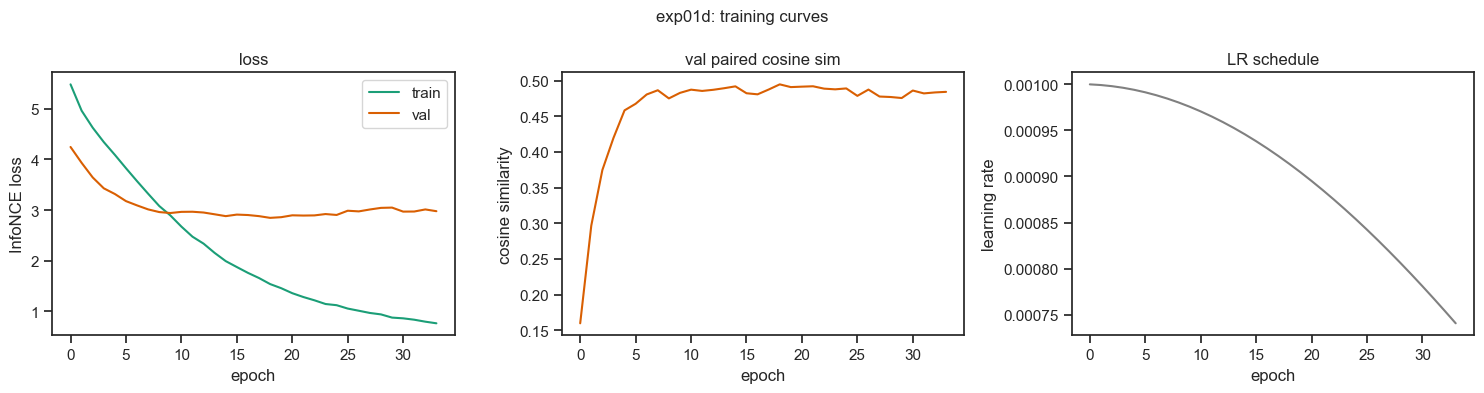

In [22]:
# training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('InfoNCE loss')
axes[0].set_title('loss')
axes[0].legend()

axes[1].plot(history['val_paired_cosine'], color='#d95f02')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('cosine similarity')
axes[1].set_title('val paired cosine sim')

axes[2].plot(history['lr'], color='gray')
axes[2].set_xlabel('epoch')
axes[2].set_ylabel('learning rate')
axes[2].set_title('LR schedule')

plt.suptitle(f'{EXP_ID}: training curves', fontsize=12)
plt.tight_layout()
plt.show()

## evaluation

In [23]:
def retrieval_metrics(query_emb, gallery_emb, ks=[1, 5, 10]):
    """compute Recall@K and MRR. assumes query[i] matches gallery[i]."""
    sim = cosine_similarity(query_emb, gallery_emb)
    ranks = (-sim).argsort(axis=1)
    n = len(query_emb)
    correct_ranks = np.array([np.where(ranks[i] == i)[0][0] for i in range(n)])
    results = {}
    for k in ks:
        results[f'recall@{k}'] = float((correct_ranks < k).mean())
    results['mrr'] = float((1.0 / (correct_ranks + 1)).mean())
    results['median_rank'] = float(np.median(correct_ranks))
    return results, correct_ranks


# aligned retrieval on test set
he_test_aligned, st_test_aligned = compute_aligned_embeddings(model, he_test, st_test)
n_test = len(he_test)

he2st, he2st_ranks = retrieval_metrics(he_test_aligned, st_test_aligned)
st2he, st2he_ranks = retrieval_metrics(st_test_aligned, he_test_aligned)

# baselines
random_baseline = {
    'recall@1': 1.0 / n_test, 'recall@5': 5.0 / n_test,
    'recall@10': 10.0 / n_test, 'mrr': sum(1.0/(i+1) for i in range(n_test)) / n_test,
}

# unaligned: zero-padded concat (orthogonal subspaces -> random retrieval)
# included for completeness but always equals random
unaligned_baseline = random_baseline.copy()

# summary table
print(f'={"=" * 69}')
print(f'{EXP_ID}: {CONFIG["he_encoder"]} + {CONFIG["st_encoder"]} | split={CONFIG["split"]} | n_test={n_test}')
print(f'raw signal: K-NN overlap={knn_overlap_fraction:.1%} (R@1 ceiling ~{knn_overlap_fraction:.3f})')
print(f'={"=" * 69}')
print(f'{"method":<25} {"R@1":>8} {"R@5":>8} {"R@10":>8} {"MRR":>8} {"med_rank":>10}')
print('-' * 69)
print(f'{"random":<25} {random_baseline["recall@1"]:>8.4f} {random_baseline["recall@5"]:>8.4f} {random_baseline["recall@10"]:>8.4f} {random_baseline["mrr"]:>8.4f} {n_test/2:>10.0f}')
print(f'{"unaligned (orthogonal)":<25} {"= random":>8} {"":>8} {"":>8} {"":>8} {"":>10}')
print(f'{"aligned H&E->ST":<25} {he2st["recall@1"]:>8.4f} {he2st["recall@5"]:>8.4f} {he2st["recall@10"]:>8.4f} {he2st["mrr"]:>8.4f} {he2st["median_rank"]:>10.0f}')
print(f'{"aligned ST->H&E":<25} {st2he["recall@1"]:>8.4f} {st2he["recall@5"]:>8.4f} {st2he["recall@10"]:>8.4f} {st2he["mrr"]:>8.4f} {st2he["median_rank"]:>10.0f}')
print('-' * 69)

aligned_r1 = (he2st['recall@1'] + st2he['recall@1']) / 2
beats_random = aligned_r1 > random_baseline['recall@1']
amplification = aligned_r1 / knn_overlap_fraction if knn_overlap_fraction > 0 else 0

print(f'\naligned mean R@1: {aligned_r1:.4f}')
print(f'vs raw signal ceiling: {knn_overlap_fraction:.4f}')
print(f'amplification: {amplification:.2f}x')
if aligned_r1 < random_baseline['recall@1']:
    print('-> alignment WORSE than random (destroyed signal through overfitting)')
elif aligned_r1 < knn_overlap_fraction:
    print('-> alignment worse than raw structure (not amplifying signal)')
elif aligned_r1 > knn_overlap_fraction:
    print('-> alignment AMPLIFYING cross-modal signal')
else:
    print('-> alignment matching raw structure (no amplification)')

exp01d: uni2_reinhard + novae | split=random_spot_80_10_10 | n_test=317
raw signal: K-NN overlap=8.5% (R@1 ceiling ~0.085)
method                         R@1      R@5     R@10      MRR   med_rank
---------------------------------------------------------------------
random                      0.0032   0.0158   0.0315   0.0200        158
unaligned (orthogonal)    = random                                      
aligned H&E->ST             0.1230   0.3754   0.5552   0.2496          8
aligned ST->H&E             0.1356   0.3565   0.5047   0.2530          9
---------------------------------------------------------------------

aligned mean R@1: 0.1293
vs raw signal ceiling: 0.0854
amplification: 1.51x
-> alignment AMPLIFYING cross-modal signal


## diagnostics

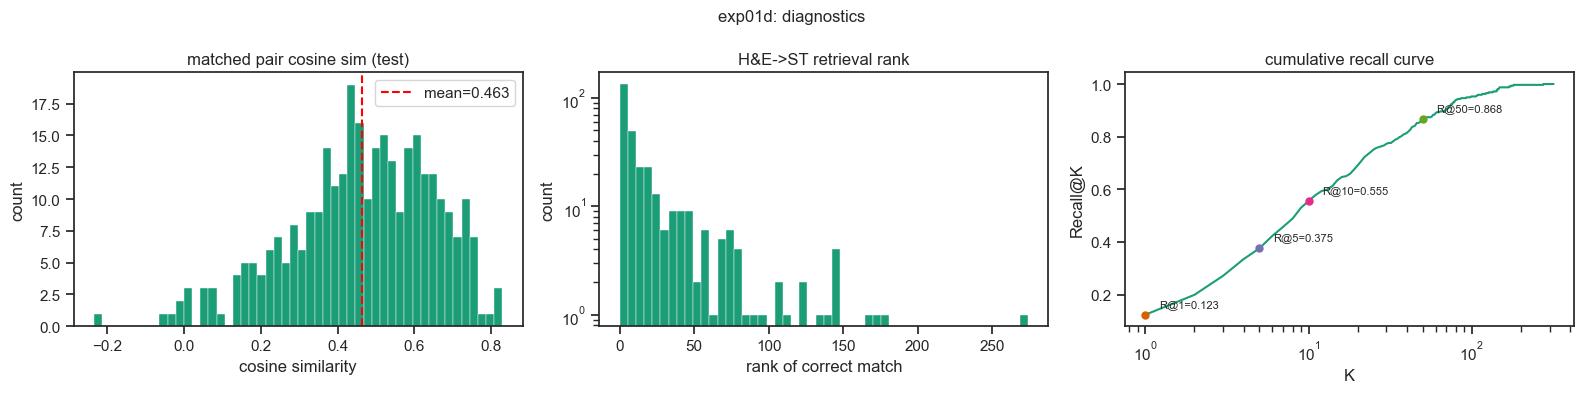

paired cosine sim: mean=0.4635, std=0.1876


In [24]:
# paired cosine sim distribution on test set
pair_sims = np.sum(he_test_aligned * st_test_aligned, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# paired cosine sim
axes[0].hist(pair_sims, bins=50, edgecolor='white', linewidth=0.3)
axes[0].axvline(pair_sims.mean(), color='red', ls='--', label=f'mean={pair_sims.mean():.3f}')
axes[0].set_xlabel('cosine similarity')
axes[0].set_ylabel('count')
axes[0].set_title('matched pair cosine sim (test)')
axes[0].legend()

# rank distribution
axes[1].hist(he2st_ranks, bins=50, edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('rank of correct match')
axes[1].set_ylabel('count')
axes[1].set_title('H&E->ST retrieval rank')
axes[1].set_yscale('log')

# cumulative recall
ks = np.arange(1, n_test + 1)
recall_curve = np.array([(he2st_ranks < k).mean() for k in ks])
axes[2].plot(ks, recall_curve)
axes[2].set_xlabel('K')
axes[2].set_ylabel('Recall@K')
axes[2].set_title('cumulative recall curve')
axes[2].set_xscale('log')
for k in [1, 5, 10, 50]:
    r = (he2st_ranks < k).mean()
    axes[2].plot(k, r, 'o', markersize=5)
    axes[2].annotate(f'R@{k}={r:.3f}', (k, r), textcoords='offset points',
                      xytext=(10, 5), fontsize=8)

plt.suptitle(f'{EXP_ID}: diagnostics', fontsize=12)
plt.tight_layout()
plt.show()

print(f'paired cosine sim: mean={pair_sims.mean():.4f}, std={pair_sims.std():.4f}')

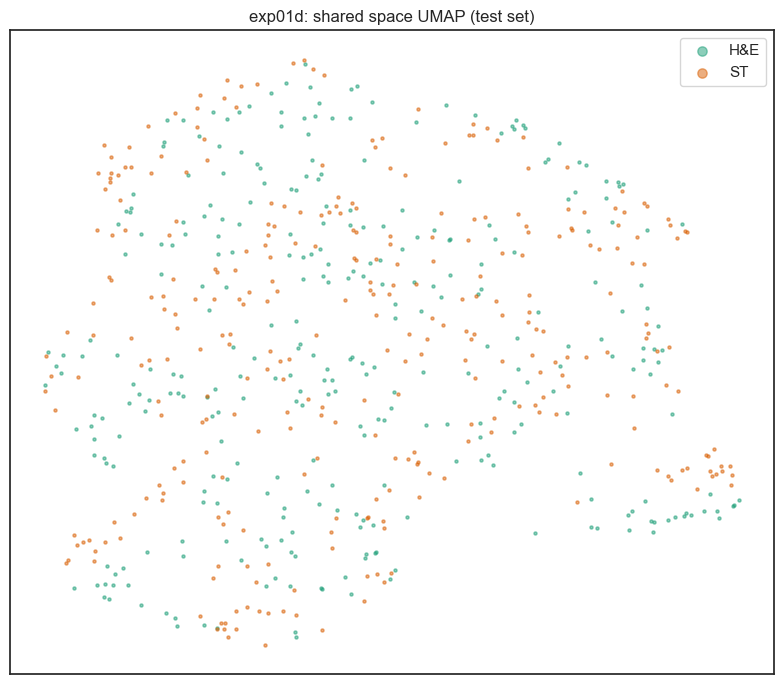

In [25]:
# UMAP of shared space
import umap

combined = np.vstack([he_test_aligned, st_test_aligned])
modality_labels = ['H&E'] * n_test + ['ST'] * n_test

reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=SEED)
umap_combined = reducer.fit_transform(combined)

fig, ax = plt.subplots(figsize=(8, 7))
for mod, color in [('H&E', '#1b9e77'), ('ST', '#d95f02')]:
    mask = np.array(modality_labels) == mod
    ax.scatter(umap_combined[mask, 0], umap_combined[mask, 1],
               s=5, alpha=0.5, label=mod, c=color)
ax.set_title(f'{EXP_ID}: shared space UMAP (test set)')
ax.legend(markerscale=3)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

## save run

In [26]:
run_dir = RUNS_DIR / EXP_ID
run_dir.mkdir(parents=True, exist_ok=True)

results = {
    'config': CONFIG,
    'metrics': {
        'he2st': he2st,
        'st2he': st2he,
        'recall_at_1': aligned_r1,
        'paired_cosine_sim': float(pair_sims.mean()),
        'paired_cosine_std': float(pair_sims.std()),
        'knn_overlap_fraction': float(knn_overlap_fraction),
        'amplification': float(amplification),
    },
    'baselines': {
        'random': random_baseline,
        'unaligned': 'equals random (orthogonal subspaces)',
    },
    'training': {
        'best_metric_name': es_metric,
        'best_metric_value': best_metric,
        'best_val_paired_cosine': max(history['val_paired_cosine']),
        'epochs_actual': len(history['train_loss']),
    },
}

with open(run_dir / 'results.json', 'w') as f:
    json.dump(results, f, indent=2)
with open(run_dir / 'history.json', 'w') as f:
    json.dump(history, f)
torch.save(best_state, run_dir / 'model.pt')

print(f'saved to runs/tnbc-92/{EXP_ID}/')
for f in sorted(run_dir.iterdir()):
    print(f'  {f.name} ({f.stat().st_size / 1024:.0f} KB)')


saved to runs/tnbc-92/exp01d/
  history.json (3 KB)
  model.pt (5260 KB)
  results.json (2 KB)


## compare all runs

In [27]:
runs = sorted(RUNS_DIR.glob('exp*/results.json'))
if len(runs) > 1:
    rows = []
    for r in runs:
        res = json.loads(r.read_text())
        cfg = res.get('config', {})
        met = res.get('metrics', {})
        # handle exp01 format (no config/metrics nesting)
        if not met:
            aligned = res.get('aligned', {})
            h2s = aligned.get('he2st', {})
            s2h = aligned.get('st2he', {})
            r1 = (h2s.get('recall@1', 0) + s2h.get('recall@1', 0)) / 2
            pcos = res.get('paired_cosine_sim', {}).get('mean', None)
            met = {'recall_at_1': r1, 'paired_cosine_sim': pcos, 'amplification': None}
        rows.append({
            'exp': r.parent.name,
            'split': cfg.get('split', 'patient_held_out'),
            'batch': cfg.get('batch_size', 256),
            'lr': cfg.get('lr', 1e-3),
            'R@1': met.get('recall_at_1'),
            'paired_cos': met.get('paired_cosine_sim'),
            'amplification': met.get('amplification'),
        })
    df = pd.DataFrame(rows).sort_values('R@1', ascending=False, na_position='last')
    print(df.to_string(index=False))
else:
    print(f'only 1 run so far ({runs[0].parent.name}). run more experiments to compare.')


   exp                split  batch    lr      R@1  paired_cos  amplification
exp01b random_spot_80_10_10    256 0.001 0.135647    0.401811       1.587839
exp01d random_spot_80_10_10    256 0.001 0.129338    0.463483       1.513986
 exp01     patient_held_out    256 0.001 0.002140    0.159677            NaN
